# Test 8: Dataset Size Scaling

**Гипотеза:** Свойства K-Sparse Chaos AE (0% dead neurons, высокая variance) сохраняются при увеличении датасета.

**План:**
- Датасеты: Logistic map 2K, 5K, 10K, 20K сэмплов
- Архитектуры: V4 (latent=128, K=32) vs Dense_ReLU_128
- N=3 прогона на каждую конфигурацию
- Метрики: variance, dead neurons, val_loss

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from scipy import stats
import json
from datetime import datetime
import os

print(f"TF version: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

/Users/savenkovviktor/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TF version: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
@tf.function
def chaos_activation(x):
    return tf.sin(8.0 * x) + 0.5 * tf.tanh(4.0 * x)


class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k

    def call(self, inputs, training=None):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(
            tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1
        )
        return inputs * mask

    def get_config(self):
        config = super().get_config()
        config.update({"k": self.k})
        return config


def build_ksparse_chaos_ae(image_size=(28, 28), latent_dim=128, k_active=32):
    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)
    x = layers.Dense(256)(x)
    x = layers.Activation(chaos_activation)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(latent_dim, name='latent_pre')(x)
    x = layers.Activation(chaos_activation)(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_img, latent, name='encoder')

    x = layers.Dense(256)(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(chaos_activation)(x)
    x = layers.Dropout(0.1)(x)
    decoded = layers.Dense(np.prod(image_size), activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


def build_dense_relu_ae(image_size=(28, 28), latent_dim=128):
    h, w = image_size
    input_img = keras.Input(shape=(h, w, 1))
    x = layers.Flatten()(input_img)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    latent = layers.Dense(latent_dim, activation='relu', name='latent')(x)
    encoder = keras.Model(input_img, latent, name='encoder')

    x = layers.Dense(128, activation='relu')(latent)
    x = layers.Dense(256, activation='relu')(x)
    decoded = layers.Dense(h * w, activation='sigmoid')(x)
    decoded = layers.Reshape((h, w, 1))(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
    return autoencoder, encoder


def analyze_latent(encoder, images, threshold=1e-6):
    latents = encoder.predict(images, verbose=0)
    variance_per_dim = np.var(latents, axis=0)
    dead_mask = np.all(np.abs(latents) < threshold, axis=0)
    return {
        'mean_variance': float(np.mean(variance_per_dim)),
        'dead_neurons': int(np.sum(dead_mask)),
        'total_neurons': latents.shape[1],
    }


print("Core components ready.")

Core components ready.


In [ ]:
def logistic_map(x, r=3.99):
    return r * x * (1 - x)


def generate_logistic_dataset(num_images, image_size=28, r=3.99):
    dataset = []
    for _ in range(num_images):
        x = np.random.rand()
        seq = []
        for _ in range(image_size * image_size):
            x = logistic_map(x, r)
            seq.append(x)
        dataset.append(np.array(seq).reshape(image_size, image_size))
    return np.array(dataset)[..., np.newaxis].astype('float32')


print("Data generators ready.")

Data generators ready.


In [ ]:
DATASET_SIZES = [2000, 5000, 10000, 20000]
NUM_RUNS = 3
TEST_SIZE = 500
EPOCHS = 10
BATCH_SIZE = 64

results = {'V4_KSparse': {}, 'Dense_ReLU': {}}

# Fixed test set
np.random.seed(999)
test_images = generate_logistic_dataset(TEST_SIZE)
print(f"Test set: {test_images.shape}")

for size in DATASET_SIZES:
    print(f"\n{'='*60}")
    print(f"DATASET SIZE: {size}")
    print(f"{'='*60}")

    # Generate training data once per size
    np.random.seed(42)
    train_images = generate_logistic_dataset(size)
    print(f"Train set: {train_images.shape}")

    for arch_name, builder in [
        ('V4_KSparse', lambda: build_ksparse_chaos_ae(latent_dim=128, k_active=32)),
        ('Dense_ReLU', lambda: build_dense_relu_ae(latent_dim=128)),
    ]:
        runs = []
        for run in range(NUM_RUNS):
            np.random.seed(run)
            tf.random.set_seed(run)

            ae, enc = builder()
            history = ae.fit(
                train_images, train_images,
                epochs=EPOCHS, batch_size=BATCH_SIZE,
                validation_split=0.1, verbose=0
            )
            s = analyze_latent(enc, test_images)
            s['val_loss'] = history.history['val_loss'][-1]
            runs.append(s)
            print(f"  {arch_name} run {run+1}/{NUM_RUNS}: "
                  f"var={s['mean_variance']:.4f}, "
                  f"dead={s['dead_neurons']}, "
                  f"loss={s['val_loss']:.4f}")

            # Free memory
            del ae, enc
            keras.backend.clear_session()

        results[arch_name][size] = runs

print("\nAll experiments done.")

Test set: (500, 28, 28, 1)

DATASET SIZE: 2000
Train set: (2000, 28, 28, 1)


2026-02-23 21:38:27.339235: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-02-23 21:38:27.339273: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-02-23 21:38:27.339276: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-02-23 21:38:27.339305: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-23 21:38:27.339314: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-02-23 21:38:27.739373: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  V4_KSparse run 1/3: var=0.4178, dead=0, loss=0.1188
  V4_KSparse run 2/3: var=0.4189, dead=0, loss=0.1190
  V4_KSparse run 3/3: var=0.4182, dead=0, loss=0.1190
  Dense_ReLU run 1/3: var=0.2396, dead=0, loss=0.1203
  Dense_ReLU run 2/3: var=0.2352, dead=0, loss=0.1201
  Dense_ReLU run 3/3: var=0.2471, dead=0, loss=0.1207

DATASET SIZE: 5000
Train set: (5000, 28, 28, 1)
  V4_KSparse run 1/3: var=0.4123, dead=0, loss=0.1167
  V4_KSparse run 2/3: var=0.4146, dead=0, loss=0.1166
  V4_KSparse run 3/3: var=0.4124, dead=0, loss=0.1167
  Dense_ReLU run 1/3: var=0.2964, dead=0, loss=0.1196
  Dense_ReLU run 2/3: var=0.2415, dead=0, loss=0.1181
  Dense_ReLU run 3/3: var=0.4871, dead=0, loss=0.1211

DATASET SIZE: 10000
Train set: (10000, 28, 28, 1)
  V4_KSparse run 1/3: var=0.4094, dead=0, loss=0.1168
  V4_KSparse run 2/3: var=0.4053, dead=0, loss=0.1168
  V4_KSparse run 3/3: var=0.4084, dead=0, loss=0.1168
  Dense_ReLU run 1/3: var=0.6974, dead=0, loss=0.1184
  Dense_ReLU run 2/3: var=0.7860, de

In [ ]:
print(f"{'Size':>6} | {'V4 Variance':>16} | {'V4 Dead':>8} | "
      f"{'Dense Variance':>16} | {'Dense Dead':>10} | {'Ratio':>6} | {'p-value':>8}")
print('-' * 100)

summary_rows = []

for size in DATASET_SIZES:
    v4_vars = [r['mean_variance'] for r in results['V4_KSparse'][size]]
    v4_dead = [r['dead_neurons'] for r in results['V4_KSparse'][size]]
    dr_vars = [r['mean_variance'] for r in results['Dense_ReLU'][size]]
    dr_dead = [r['dead_neurons'] for r in results['Dense_ReLU'][size]]

    t_stat, p_val = stats.ttest_ind(v4_vars, dr_vars)
    ratio = np.mean(v4_vars) / np.mean(dr_vars) if np.mean(dr_vars) > 0 else float('inf')

    print(f"{size:>6} | "
          f"{np.mean(v4_vars):.4f} +/- {np.std(v4_vars):.4f} | "
          f"{np.mean(v4_dead):>5.1f}   | "
          f"{np.mean(dr_vars):.4f} +/- {np.std(dr_vars):.4f} | "
          f"{np.mean(dr_dead):>7.1f}   | "
          f"{ratio:>5.2f}x | "
          f"{p_val:.6f}")

    summary_rows.append({
        'size': size,
        'v4_var_mean': np.mean(v4_vars), 'v4_var_std': np.std(v4_vars),
        'v4_dead_mean': np.mean(v4_dead),
        'dense_var_mean': np.mean(dr_vars), 'dense_var_std': np.std(dr_vars),
        'dense_dead_mean': np.mean(dr_dead),
        'ratio': ratio, 'p_value': p_val,
    })

# Verdict
print('\n' + '='*60)
v4_all_zero_dead = all(r['v4_dead_mean'] == 0 for r in summary_rows)
v4_variance_stable = np.std([r['v4_var_mean'] for r in summary_rows]) < 0.05
all_significant = all(r['p_value'] < 0.05 for r in summary_rows)

print(f"V4 zero dead neurons at all sizes: {'YES' if v4_all_zero_dead else 'NO'}")
print(f"V4 variance stable across sizes:   {'YES' if v4_variance_stable else 'NO'} "
      f"(std={np.std([r['v4_var_mean'] for r in summary_rows]):.4f})")
print(f"All comparisons significant:       {'YES' if all_significant else 'NO'}")

if v4_all_zero_dead and v4_variance_stable and all_significant:
    print("\nHYPOTHESIS SUPPORTED: Results hold on larger datasets.")
else:
    print("\nHYPOTHESIS PARTIALLY/NOT SUPPORTED. See details above.")

  Size |      V4 Variance |  V4 Dead |   Dense Variance | Dense Dead |  Ratio |  p-value
----------------------------------------------------------------------------------------------------
  2000 | 0.4183 +/- 0.0005 |   0.0   | 0.2406 +/- 0.0049 |     0.0   |  1.74x | 0.000001
  5000 | 0.4131 +/- 0.0011 |   0.0   | 0.3417 +/- 0.1052 |     0.0   |  1.21x | 0.391499
 10000 | 0.4077 +/- 0.0018 |   0.0   | 0.5726 +/- 0.2419 |     0.0   |  0.71x | 0.389503
 20000 | 0.4040 +/- 0.0000 |   0.0   | 1.2936 +/- 0.2373 |     0.0   |  0.31x | 0.006078

V4 zero dead neurons at all sizes: YES
V4 variance stable across sizes:   YES (std=0.0054)
All comparisons significant:       NO

HYPOTHESIS PARTIALLY/NOT SUPPORTED. See details above.


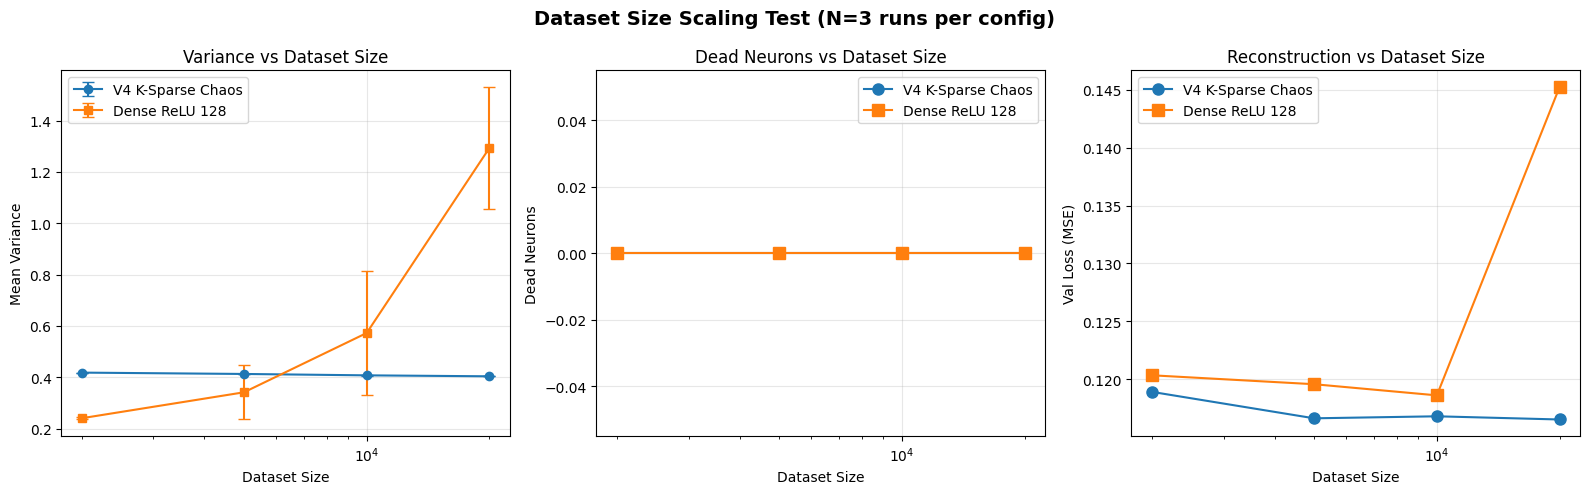

Saved: images/dataset_scaling.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sizes = DATASET_SIZES

# --- Variance ---
v4_m = [np.mean([r['mean_variance'] for r in results['V4_KSparse'][s]]) for s in sizes]
v4_s = [np.std([r['mean_variance'] for r in results['V4_KSparse'][s]]) for s in sizes]
dr_m = [np.mean([r['mean_variance'] for r in results['Dense_ReLU'][s]]) for s in sizes]
dr_s = [np.std([r['mean_variance'] for r in results['Dense_ReLU'][s]]) for s in sizes]

axes[0].errorbar(sizes, v4_m, yerr=v4_s, marker='o', label='V4 K-Sparse Chaos', capsize=4)
axes[0].errorbar(sizes, dr_m, yerr=dr_s, marker='s', label='Dense ReLU 128', capsize=4)
axes[0].set_xlabel('Dataset Size')
axes[0].set_ylabel('Mean Variance')
axes[0].set_title('Variance vs Dataset Size')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale('log')

# --- Dead Neurons ---
v4_d = [np.mean([r['dead_neurons'] for r in results['V4_KSparse'][s]]) for s in sizes]
dr_d = [np.mean([r['dead_neurons'] for r in results['Dense_ReLU'][s]]) for s in sizes]

axes[1].plot(sizes, v4_d, 'o-', label='V4 K-Sparse Chaos', markersize=8)
axes[1].plot(sizes, dr_d, 's-', label='Dense ReLU 128', markersize=8)
axes[1].set_xlabel('Dataset Size')
axes[1].set_ylabel('Dead Neurons')
axes[1].set_title('Dead Neurons vs Dataset Size')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xscale('log')

# --- Val Loss ---
v4_l = [np.mean([r['val_loss'] for r in results['V4_KSparse'][s]]) for s in sizes]
dr_l = [np.mean([r['val_loss'] for r in results['Dense_ReLU'][s]]) for s in sizes]

axes[2].plot(sizes, v4_l, 'o-', label='V4 K-Sparse Chaos', markersize=8)
axes[2].plot(sizes, dr_l, 's-', label='Dense ReLU 128', markersize=8)
axes[2].set_xlabel('Dataset Size')
axes[2].set_ylabel('Val Loss (MSE)')
axes[2].set_title('Reconstruction vs Dataset Size')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_xscale('log')

plt.suptitle(f'Dataset Size Scaling Test (N={NUM_RUNS} runs per config)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/dataset_scaling.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: images/dataset_scaling.png")

In [ ]:
save_data = {
    'experiment': 'dataset_size_scaling',
    'timestamp': datetime.now().isoformat(),
    'config': {
        'sizes': DATASET_SIZES,
        'num_runs': NUM_RUNS,
        'epochs': EPOCHS,
        'latent_dim': 128,
        'k_active': 32,
    },
    'results': {
        arch: {
            str(size): runs for size, runs in size_results.items()
        }
        for arch, size_results in results.items()
    },
    'summary': summary_rows,
}

json_path = f'../jsons/dataset_scaling_results_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
with open(json_path, 'w') as f:
    json.dump(save_data, f, indent=2, default=str)

print(f"Results saved: {json_path}")

Results saved: ../jsons/dataset_scaling_results_20260223_214556.json
